# Step 1: Linear Algebra Essentials for Transformers

Welcome! This is the first notebook in our **"Learn Transformers from Scratch"** series.

Before we can understand how Transformers work, we need a handful of linear algebra building blocks. The good news: you don't need a math degree — just these five concepts:

1. **Vectors & Matrices** — the containers that hold all data in a Transformer
2. **Dot Product** — how a Transformer measures *similarity* between things
3. **Matrix Multiplication** — how a Transformer processes many things at once
4. **Transpose** — a simple reshaping trick you'll see everywhere
5. **Softmax** — how raw scores become probabilities (the secret sauce of attention)

Let's dive in!

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.rcParams['figure.figsize'] = (6, 3)
plt.rcParams['font.size'] = 12

---
## 1. Vectors and Matrices

**Vector** = a list of numbers. Think of it as a point (or arrow) in space.  
**Matrix** = a grid (table) of numbers — rows and columns.

In a Transformer, every word is represented as a **vector** (a list of, say, 512 numbers). A whole sentence is a **matrix** — one row per word.

In [7]:
# Creating vectors
v = np.array([1, 2, 3])
print("Vector v:", v)
print("Shape:", v.shape)  # (3,) means 3 elements, 1-D

# Creating matrices
M = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
print("\nMatrix M:")
print(M)
print("Shape:", M.shape)  # (2, 3) means 2 rows, 3 columns

Vector v: [1 2 3]
Shape: (3,)

Matrix M:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)


In [9]:
# Indexing — grab specific elements
print("First element of v:", v[0])        # 1
print("Element at row 1, col 2 of M:", M[1, 2])  # 6
print("First row of M:", M[0])            # [1, 2, 3]
print("Second column of M:", M[:, 1])     # [2, 5]

First element of v: 1
Element at row 1, col 2 of M: 6
First row of M: [1 2 3]
Second column of M: [2 5]


In [11]:
# Handy ways to create arrays
print("Zeros:", np.zeros(4))
print("Ones:", np.ones((2, 3)))
print("Range:", np.arange(5))
print("Random:", np.random.randn(3))  # 3 random numbers from a normal distribution

Zeros: [0. 0. 0. 0.]
Ones: [[1. 1. 1.]
 [1. 1. 1.]]
Range: [0 1 2 3 4]
Random: [0.89040886 0.87229474 0.89753766]


### Exercise 1: Vectors & Matrices

1. Create a vector of length 5 containing the values `[10, 20, 30, 40, 50]`.
2. Create a 3×3 matrix where every element is 7.
3. From your vector, extract the last two elements using slicing.

In [13]:
# ✏️ Your code here
v1 = np.array([10,20,30,40,50])
m1 = np.full((3,3,),7)
v1[-2:]

array([40, 50])

In [9]:
# ---------- Solution ----------
v1 = np.array([10, 20, 30, 40, 50])
print("Vector:", v1)

m1 = np.full((3, 3), 7)
print("Matrix of 7s:\n", m1)

print("Last two elements:", v1[-2:])

Vector: [10 20 30 40 50]
Matrix of 7s:
 [[7 7 7]
 [7 7 7]
 [7 7 7]]
Last two elements: [40 50]


In [11]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# By hand
dot_by_hand = 1*4 + 2*5 + 3*6
print("Dot product by hand:", dot_by_hand)

# With NumPy
dot_numpy = np.dot(a, b)
print("Dot product (np.dot):", dot_numpy)

# Also works with @
print("Dot product (@ operator):", a @ b)

Dot product by hand: 32
Dot product (np.dot): 32
Dot product (@ operator): 32


Similarity(king, queen) = 1.220
Similarity(king, car) = 0.080
Similarity(queen, car) = 0.020


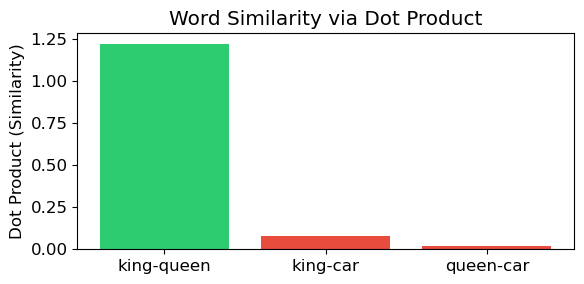

In [12]:
# Dot product as similarity: toy word vectors
# Imagine each dimension represents a concept: [royalty, gender, age]
king  = np.array([0.9, 0.8, 0.5])
queen = np.array([0.9, 0.2, 0.5])
car   = np.array([0.0, 0.1, 0.0])

words = {'king': king, 'queen': queen, 'car': car}
pairs = [('king', 'queen'), ('king', 'car'), ('queen', 'car')]

similarities = []
labels = []
for w1, w2 in pairs:
    sim = np.dot(words[w1], words[w2])
    similarities.append(sim)
    labels.append(f"{w1}-{w2}")
    print(f"Similarity({w1}, {w2}) = {sim:.3f}")

# Visualize
plt.bar(labels, similarities, color=['#2ecc71', '#e74c3c', '#e74c3c'])
plt.ylabel('Dot Product (Similarity)')
plt.title('Word Similarity via Dot Product')
plt.tight_layout()
plt.show()

---
## 3. Matrix Multiplication

Matrix multiplication is just **many dot products at once**.

If `A` is (m × n) and `B` is (n × p), the result is (m × p).  
**Key rule:** the inner dimensions must match (the `n`s).

Each element in the result is the dot product of a row from A with a column from B.

In [14]:
A = np.array([[1, 2],
              [3, 4]])   # 2x2

B = np.array([[5, 6],
              [7, 8]])   # 2x2

# Let's compute the top-left element by hand:
# Row 0 of A dot Column 0 of B = 1*5 + 2*7 = 19
print("Top-left element by hand:", 1*5 + 2*7)

# Full matrix multiplication
C = A @ B  # same as np.matmul(A, B)
print("\nA @ B =")
print(C)

Top-left element by hand: 19

A @ B =
[[19 22]
 [43 50]]


In [26]:
# Non-square example: (2x3) @ (3x2) = (2x2)
X = np.array([[1, 2, 3],
              [4, 5, 6]])   # 2x3

W = np.array([[0.1, 0.4],
              [0.2, 0.5],
              [0.3, 0.6]])  # 3x2

result = X @ W
print(f"X shape: {X.shape}, W shape: {W.shape} -> result shape: {result.shape}")
print("Result:")
print(result)

# This is exactly what happens in a Transformer layer:
# X = input embeddings (sentences x features)
# W = weight matrix (features x output_features)
# X @ W = transformed output

X shape: (2, 3), W shape: (3, 2) -> result shape: (2, 2)
Result:
[[1.4 3.2]
 [3.2 7.7]]


### Exercise 2: Matrix Multiplication

Given:
```
P = [[1, 0],
     [0, 1],
     [2, 3]]

Q = [[4, 1, 0],
     [2, 0, 5]]
```

1. What will the shape of `P @ Q` be?
2. Compute `P @ Q` by hand for the element at position (2, 2) — that is, row 2, column 2.
3. Verify with NumPy.

In [20]:
# ✏️ Your code here
P = np.array([[1,0], [0,1], [2,3]])
Q = np.array([[4,1,0], [2,0,5]])
print("Shape of P @ Q", (P @ Q).shape)

Shape of P @ Q (3, 3)


In [ ]:
# ---------- Solution ----------
P = np.array([[1, 0], [0, 1], [2, 3]])
Q = np.array([[4, 1, 0], [2, 0, 5]])

print("Shape of P @ Q:", (P @ Q).shape)  # (3, 3)

# Element at (2, 2): row 2 of P dot col 2 of Q
# [2, 3] dot [0, 5] = 0 + 15 = 15
print("Element (2,2) by hand:", 2*0 + 3*5)

print("Full result:")
print(P @ Q)

---
## 4. Transpose

**Transpose** flips a matrix over its diagonal — rows become columns and vice versa.

A matrix of shape (m × n) becomes (n × m).

Why do we care? In Transformers, we often need to compute `Q @ K^T` (queries times the transpose of keys) to get attention scores. The transpose makes the dimensions line up for matrix multiplication.

In [ ]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Original (2x3):")
print(M)

print("\nTransposed (3x2):")
print(M.T)

print(f"\nShape: {M.shape} -> {M.T.shape}")

In [ ]:
# Practical use: computing similarity between all pairs of vectors
# Suppose we have 3 word vectors, each of dimension 4
words_matrix = np.random.randn(3, 4)  # 3 words, 4 features each
print("Words matrix shape:", words_matrix.shape)

# Q @ K^T gives a (3x3) matrix of pairwise similarities
# This is the core of attention!
similarity_matrix = words_matrix @ words_matrix.T
print("Similarity matrix shape:", similarity_matrix.shape)
print("Similarity matrix:")
print(np.round(similarity_matrix, 2))

---
## 5. Softmax — Turning Scores into Probabilities

The **softmax** function takes a vector of arbitrary numbers and squishes them into **probabilities** (positive numbers that sum to 1):

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Analogy:** Imagine you have exam scores [90, 80, 50]. Softmax says *"90 is the biggest, so it gets the most probability; 50 gets very little."* It preserves the ranking but normalizes everything to sum to 1.

In Transformers, softmax converts raw attention scores into attention *weights*.

In [27]:
def softmax(x):
    """Compute softmax from scratch."""
    # Subtract max for numerical stability (prevents overflow)
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)

print("Raw scores:", scores)
print("After softmax:", np.round(probs, 4))
print("Sum:", np.round(probs.sum(), 4))  # Should be 1.0

Raw scores: [2.  1.  0.1]
After softmax: [0.659  0.2424 0.0986]
Sum: 1.0


In [29]:
# Compare with scipy
from scipy.special import softmax as scipy_softmax

ours = softmax(scores)
theirs = scipy_softmax(scores)

print("Our softmax:  ", np.round(ours, 6))
print("Scipy softmax:", np.round(theirs, 6))
print("Match:", np.allclose(ours, theirs))

Our softmax:   [0.659001 0.242433 0.098566]
Scipy softmax: [0.659001 0.242433 0.098566]
Match: True


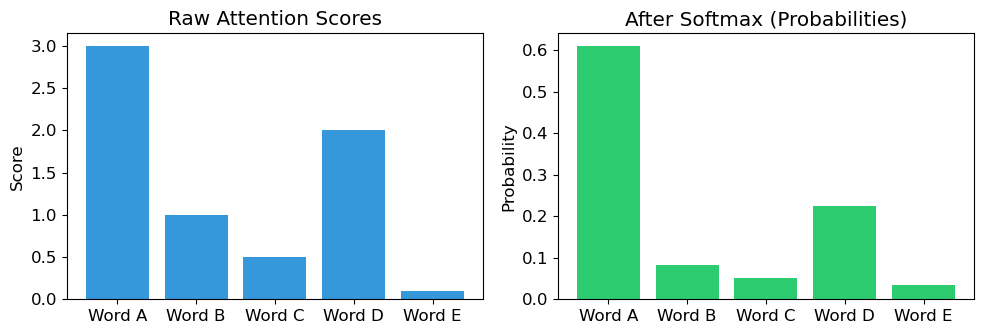

Probabilities: ['0.610', '0.083', '0.050', '0.224', '0.034']
Sum: 1.0000


In [31]:
# Visualize: how softmax sharpens differences
raw_scores = np.array([3.0, 1.0, 0.5, 2.0, 0.1])
probabilities = softmax(raw_scores)
labels = ['Word A', 'Word B', 'Word C', 'Word D', 'Word E']

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(labels, raw_scores, color='#3498db')
axes[0].set_title('Raw Attention Scores')
axes[0].set_ylabel('Score')

axes[1].bar(labels, probabilities, color='#2ecc71')
axes[1].set_title('After Softmax (Probabilities)')
axes[1].set_ylabel('Probability')

plt.tight_layout()
plt.show()

print("Probabilities:", [f"{p:.3f}" for p in probabilities])
print("Sum:", f"{probabilities.sum():.4f}")

### Exercise 3: Softmax & Putting It All Together

This exercise simulates a tiny attention computation — the heart of a Transformer!

Given three "word vectors":
```
hello = [1.0, 0.5, 0.0]
world = [0.8, 0.6, 0.1]
cat   = [0.0, 0.1, 0.9]
```

1. Stack them into a matrix `X` of shape (3, 3).
2. Compute the similarity matrix: `S = X @ X.T` (shape 3×3).
3. Apply softmax to **each row** of S (hint: use a loop or `axis` parameter).
4. Print the resulting attention weights. Which word does "hello" attend to most?

In [ ]:
# ✏️ Your code here


In [34]:
# ---------- Solution ----------
hello = np.array([1.0, 0.5, 0.0])
world = np.array([0.8, 0.6, 0.1])
cat   = np.array([0.0, 0.1, 0.9])

# 1. Stack into matrix
X = np.array([hello, world, cat])
print("X (word vectors):")
print(X)

# 2. Similarity matrix
S = X @ X.T
print("\nSimilarity matrix (X @ X^T):")
print(np.round(S, 3))

# 3. Apply softmax to each row
attention_weights = np.array([softmax(row) for row in S])
print("\nAttention weights (after softmax):")
labels = ['hello', 'world', 'cat']
for i, label in enumerate(labels):
    weights_str = ', '.join(f"{labels[j]}: {attention_weights[i, j]:.3f}" for j in range(3))
    print(f"  {label} -> [{weights_str}]")

# 4. "hello" attends most to itself (highest self-similarity), then "world"
print(f"\n'hello' attends most to: {labels[np.argmax(attention_weights[0])]}")

X (word vectors):
[[1.  0.5 0. ]
 [0.8 0.6 0.1]
 [0.  0.1 0.9]]

Similarity matrix (X @ X^T):
[[1.25 1.1  0.05]
 [1.1  1.01 0.15]
 [0.05 0.15 0.82]]

Attention weights (after softmax):
  hello -> [hello: 0.463, world: 0.398, cat: 0.139]
  world -> [hello: 0.435, world: 0.397, cat: 0.168]
  cat -> [hello: 0.234, world: 0.259, cat: 0.506]

'hello' attends most to: hello


---
## Summary

| Concept | What it does | Where it appears in Transformers |
|---|---|---|
| **Vectors** | Represent a single word/token | Embeddings |
| **Matrices** | Represent a batch of words or a weight layer | Embedding matrices, weight matrices |
| **Dot Product** | Measure similarity between two vectors | Attention scores (Q · K) |
| **Matrix Multiply** | Compute many dot products at once | Q @ K^T, attention output, feed-forward layers |
| **Transpose** | Flip rows/columns to align dimensions | K^T in attention |
| **Softmax** | Convert scores to probabilities | Attention weights |

In the next notebook, we'll use these tools to build **attention from scratch**. See you there!